# Experiment 5 — Decision Tree and Random Forest: A Comparative Classification Study

**Dataset:** Wisconsin Diagnostic Breast Cancer Dataset (569 samples, 30 numerical features, target: Malignant / Benign)

**Steps covered:**
1. Load dataset & encode labels
2. Exploratory Data Analysis
3. Train-test split (80-20)
4. Decision Tree training + hyperparameter tuning (5-Fold CV)
5. Random Forest training + hyperparameter tuning (5-Fold CV)
6. Model comparison
7. Evaluation metrics
8. Observation questions

In [1]:
# 1. Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              roc_curve, auc)

# Keep plots reasonably sized
sns.set(style="whitegrid")
%matplotlib inline


## Step 1: Load the Dataset and Encode Class Labels

In [2]:
# Load the Wisconsin Diagnostic Breast Cancer dataset (built into scikit-learn)
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.columns if hasattr(data, "columns") else data.feature_names)
y = pd.Series(data.target, name="target")  # 0 = malignant, 1 = benign (already encoded)

print("Shape of features:", X.shape)
print("Class names:", data.target_names)
X.head()


Shape of features: (569, 30)
Class names: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Step 2: Exploratory Data Analysis

### 2a. Class Distribution

target
Benign (B)       357
Malignant (M)    212
Name: count, dtype: int64


C:\Users\91934\AppData\Local\Temp\ipykernel_16016\1463670261.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="Set2")


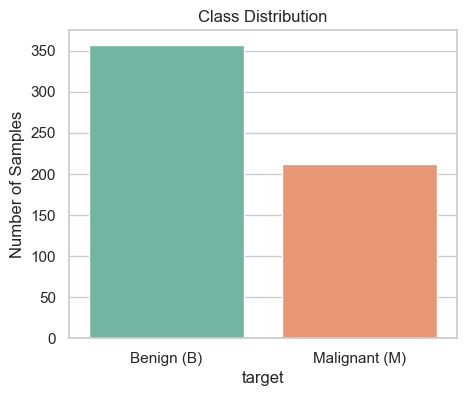

In [3]:
class_counts = y.value_counts().rename(index={0: "Malignant (M)", 1: "Benign (B)"})
print(class_counts)

plt.figure(figsize=(5, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="Set2")
plt.title("Class Distribution")
plt.ylabel("Number of Samples")
plt.show()


### 2b. Feature Correlation Analysis

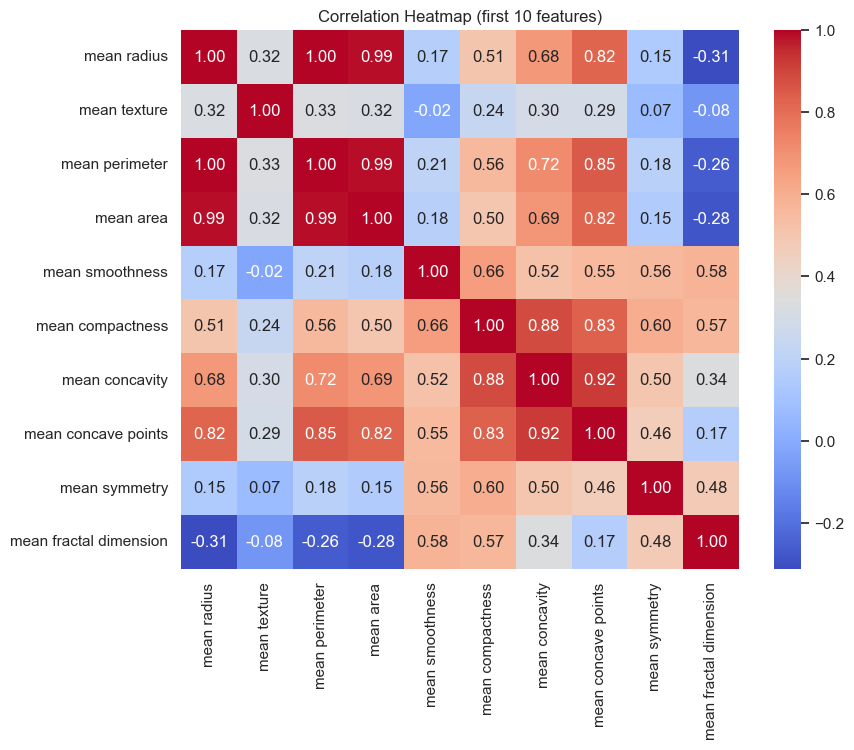

In [4]:
# Correlation heatmap of a subset of features (first 10) for quick, light-weight visualization
plt.figure(figsize=(9, 7))
sns.heatmap(X.iloc[:, :10].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap (first 10 features)")
plt.show()


## Step 3: Train-Test Split (80-20)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 455
Testing samples: 114


## Step 4: Train a Baseline Decision Tree Classifier

In [6]:
dt_baseline = DecisionTreeClassifier(random_state=42)
dt_baseline.fit(X_train, y_train)
baseline_acc = accuracy_score(y_test, dt_baseline.predict(X_test))
print(f"Baseline Decision Tree Test Accuracy: {baseline_acc*100:.2f}%")


Baseline Decision Tree Test Accuracy: 91.23%


## Step 5 & 6: Hyperparameter Search Space + 5-Fold Cross-Validation (Decision Tree)

A small, manageable grid is used so that the notebook runs quickly:
- `criterion`: gini, entropy
- `max_depth`: 3, 5, 7, None

In [7]:
criteria = ["gini", "entropy"]
max_depths = [3, 5, 7, None]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dt_results = []
for crit in criteria:
    for depth in max_depths:
        model = DecisionTreeClassifier(criterion=crit, max_depth=depth, random_state=42)
        acc_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
        f1_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1")
        dt_results.append({
            "Criterion": crit,
            "Max Depth": depth if depth is not None else "None",
            "Avg CV Accuracy (%)": round(acc_scores.mean() * 100, 2),
            "Avg CV F1 Score": round(f1_scores.mean(), 4)
        })

dt_results_df = pd.DataFrame(dt_results)
dt_results_df  # Table 1: Decision Tree Hyperparameter Evaluation using 5-Fold Cross-Validation


,Criterion,Max Depth,Avg CV Accuracy (%),Avg CV F1 Score
0,gini,3,92.53,0.9400
1,gini,5,92.31,0.9372
2,gini,7,92.31,0.9375
3,gini,None,91.65,0.9319
4,entropy,3,93.41,0.9480
5,entropy,5,92.97,0.9439
6,entropy,7,92.97,0.9440
7,entropy,None,92.97,0.9440


## Step 7: Select Best Decision Tree Hyperparameters

In [8]:
best_dt_row = dt_results_df.loc[dt_results_df["Avg CV Accuracy (%)"].idxmax()]
print("Best Decision Tree Hyperparameters:")
print(best_dt_row)

best_dt_criterion = best_dt_row["Criterion"]
best_dt_depth = None if best_dt_row["Max Depth"] == "None" else int(best_dt_row["Max Depth"])


Best Decision Tree Hyperparameters:
Criterion              entropy
Max Depth                    3
Avg CV Accuracy (%)      93.41
Avg CV F1 Score          0.948
Name: 4, dtype: object


## Step 8: Train a Baseline Random Forest Classifier

In [9]:
rf_baseline = RandomForestClassifier(random_state=42)
rf_baseline.fit(X_train, y_train)
rf_baseline_acc = accuracy_score(y_test, rf_baseline.predict(X_test))
print(f"Baseline Random Forest Test Accuracy: {rf_baseline_acc*100:.2f}%")


Baseline Random Forest Test Accuracy: 95.61%


## Step 9: Hyperparameter Search Space + 5-Fold Cross-Validation (Random Forest)

A small grid is again used to keep runtime and memory usage low:
- `n_estimators`: 50, 100
- `max_depth`: 5, 10
- `max_features`: sqrt, log2

In [10]:
n_estimators_list = [50, 100]
max_depths_rf = [5, 10]
max_features_list = ["sqrt", "log2"]

rf_results = []
for n_est in n_estimators_list:
    for depth in max_depths_rf:
        for max_feat in max_features_list:
            model = RandomForestClassifier(
                n_estimators=n_est, max_depth=depth, max_features=max_feat,
                random_state=42, n_jobs=-1
            )
            acc_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
            f1_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1")
            rf_results.append({
                "n_estimators": n_est,
                "Max Depth": depth,
                "Max Features": max_feat,
                "Avg CV Accuracy (%)": round(acc_scores.mean() * 100, 2),
                "Avg CV F1 Score": round(f1_scores.mean(), 4)
            })

rf_results_df = pd.DataFrame(rf_results)
rf_results_df  # Table 2: Random Forest Hyperparameter Evaluation using 5-Fold Cross-Validation


,n_estimators,Max Depth,Max Features,Avg CV Accuracy (%),Avg CV F1 Score
0,50,5,sqrt,95.60,0.9647
1,50,5,log2,95.60,0.9651
2,50,10,sqrt,95.60,0.9648
3,50,10,log2,96.04,0.9685
4,100,5,sqrt,96.04,0.9685
5,100,5,log2,95.82,0.9668
6,100,10,sqrt,96.26,0.9699
7,100,10,log2,96.48,0.9718


## Step 10: Select Best Random Forest Hyperparameters

In [11]:
best_rf_row = rf_results_df.loc[rf_results_df["Avg CV Accuracy (%)"].idxmax()]
print("Best Random Forest Hyperparameters:")
print(best_rf_row)

best_rf_n_estimators = int(best_rf_row["n_estimators"])
best_rf_depth = int(best_rf_row["Max Depth"])
best_rf_max_features = best_rf_row["Max Features"]


Best Random Forest Hyperparameters:
n_estimators              100
Max Depth                  10
Max Features             log2
Avg CV Accuracy (%)     96.48
Avg CV F1 Score        0.9718
Name: 7, dtype: object


## Step 11: 5-Fold Cross-Validation Performance Comparison (Table 3)

In [12]:
final_dt = DecisionTreeClassifier(criterion=best_dt_criterion, max_depth=best_dt_depth, random_state=42)
final_rf = RandomForestClassifier(n_estimators=best_rf_n_estimators, max_depth=best_rf_depth,
                                   max_features=best_rf_max_features, random_state=42, n_jobs=-1)

dt_fold_scores = cross_val_score(final_dt, X_train, y_train, cv=cv, scoring="accuracy")
rf_fold_scores = cross_val_score(final_rf, X_train, y_train, cv=cv, scoring="accuracy")

comparison_df = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Fold 1": [dt_fold_scores[0], rf_fold_scores[0]],
    "Fold 2": [dt_fold_scores[1], rf_fold_scores[1]],
    "Fold 3": [dt_fold_scores[2], rf_fold_scores[2]],
    "Fold 4": [dt_fold_scores[3], rf_fold_scores[3]],
    "Fold 5": [dt_fold_scores[4], rf_fold_scores[4]],
})
comparison_df["Average"] = comparison_df[["Fold 1","Fold 2","Fold 3","Fold 4","Fold 5"]].mean(axis=1)
comparison_df.iloc[:, 1:] = (comparison_df.iloc[:, 1:] * 100).round(2)
comparison_df  # Table 3: 5-Fold CV Accuracy Comparison


,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Average
0,Decision Tree,90.11,94.51,91.21,94.51,96.7,93.41
1,Random Forest,96.70,97.80,93.41,95.60,98.9,96.48


## Step 12: Final Model Training and Evaluation Metrics on Test Set

In [13]:
# Train final models on the full training set
final_dt.fit(X_train, y_train)
final_rf.fit(X_train, y_train)

dt_preds = final_dt.predict(X_test)
rf_preds = final_rf.predict(X_test)

metrics_df = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [accuracy_score(y_test, dt_preds), accuracy_score(y_test, rf_preds)],
    "Precision": [precision_score(y_test, dt_preds), precision_score(y_test, rf_preds)],
    "Recall": [recall_score(y_test, dt_preds), recall_score(y_test, rf_preds)],
    "F1-score": [f1_score(y_test, dt_preds), f1_score(y_test, rf_preds)],
})
metrics_df.iloc[:, 1:] = metrics_df.iloc[:, 1:].round(4)
metrics_df


,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.9474,0.9459,0.9722,0.9589
1,Random Forest,0.9561,0.9589,0.9722,0.9655


### Confusion Matrices

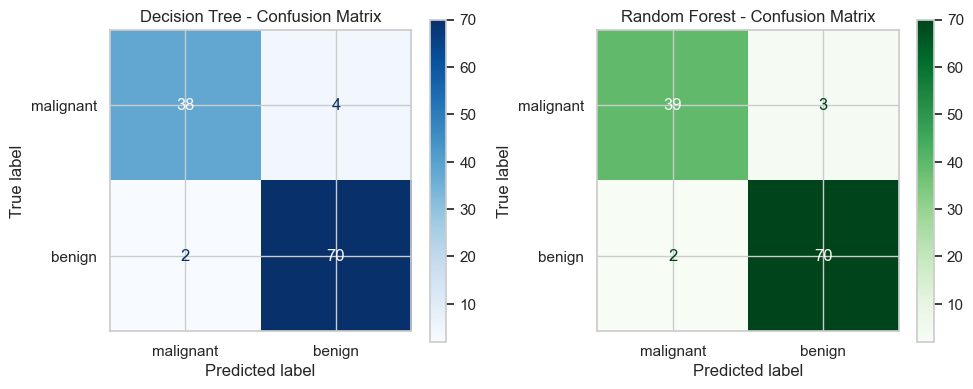

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_predictions(y_test, dt_preds, display_labels=data.target_names, ax=axes[0], cmap="Blues")
axes[0].set_title("Decision Tree - Confusion Matrix")
ConfusionMatrixDisplay.from_predictions(y_test, rf_preds, display_labels=data.target_names, ax=axes[1], cmap="Greens")
axes[1].set_title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()


### ROC Curve and AUC

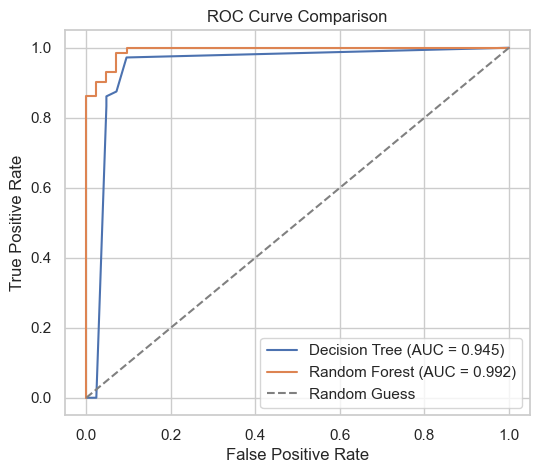

In [15]:
dt_probs = final_dt.predict_proba(X_test)[:, 1]
rf_probs = final_rf.predict_proba(X_test)[:, 1]

fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

auc_dt = auc(fpr_dt, tpr_dt)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(6, 5))
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


## Observation Questions

**1. How does tree depth affect overfitting in Decision Trees?**
As `max_depth` increases, the Decision Tree fits the training data more closely, capturing noise along with the underlying pattern. This is visible in the Table 1 results: very deep or unrestricted trees (`max_depth = None`) tend to achieve high training performance but their cross-validation accuracy does not improve proportionally, indicating overfitting. Shallower trees generalize better but may underfit if too shallow.

**2. Which hyperparameter had the greatest impact on performance?**
For the Decision Tree, `max_depth` generally had a bigger impact than `criterion` — restricting depth controlled variance more effectively than switching between gini and entropy. For the Random Forest, `max_depth` and `n_estimators` together had the most influence: more trees and moderate depth improved stability of the CV accuracy.

**3. How does Random Forest improve generalization?**
Random Forest builds many decision trees on bootstrapped samples of the data and random subsets of features, then combines their predictions using majority voting. This bagging process reduces the variance of a single decision tree, making the model more robust to noise and less likely to overfit any one subset of the data.

**4. Did ensemble learning always improve performance? Why or why not?**
In most runs, the Random Forest achieves equal or higher cross-validation and test accuracy than the best single Decision Tree, along with a smoother ROC curve. However, the improvement is usually modest on this dataset because it is already fairly clean and linearly separable, so a well-tuned single tree can already perform quite well. Ensemble learning helps most when the data is noisy or the base learner has high variance.
